# Verbal report from J-space — Qwen3-4B

When the model is told to think of a thing and name it, is the word it is about to say
already readable in J-space before it says it — and does swapping that J-space content
change what it says? This is the paper's §3.1 experiment on the committed prompt set
(`data/experiments/verbal-report.json`: 14 categories x 14 candidate words), with the
pre-fitted lens from `neuronpedia/jacobian-lens`.

Only categories the model answers correctly — with one of that category's own candidate
words — are used (§2).

**Answer (this run, §5).** Yes, on the paper's own metric, in mid-network. Qwen3-4B answers
13 of 14 categories with one of their candidate words (`bird` -> `sp` is dropped, §2). On
those, the J-lens's ranking of the candidates agrees with the model's own next-token logits
better than the logit lens does at layers 12 and 18 — Spearman rho 0.23 vs 0.13 and 0.29 vs
0.22 — and the two tie at layer 24 (0.59 vs 0.60), where `J_l` is close to the identity. So
the word the model is about to say is legible in J-space earlier in depth than in the raw
residual stream. The causal half also works and is specific: swapping the answer's J-space
coordinate for a candidate's moves that candidate to rank 1 in 44.7% of trials (alpha 2,
band 20-28; Wilson 95% CI [36.2, 53.5]) against 4.1% [1.7, 9.2] for norm-matched random
directions. One result cuts against the paper: at mid-to-late bands the *logit-lens*
directions swap better than the J-lens ones (65.9% vs 44.7%), with J ahead only in the two
early bands, where both are weak. That is the opposite of `concept_swap.ipynb` on
factual-recall prompts, where logit directions score 0.000 early — see §5.

## Method

**Prompt.** `Think of a {category}. Answer in one word.` as the user turn through Qwen3's
chat template, then the assistant prefill `My answer is:` teacher-forced, so the next
greedy token is the name. Everything is read at that final `:` — "the token position
immediately before the name is produced".

**Question filter.** A category counts as answered correctly when the model's greedy
answer at the final `:` is one of that category's candidate words (case-insensitive). The
Spearman metric compares the lens against the model's ranking of those candidates, and the
swap moves the answer to another candidate, so both need the answer to be one of them.
Categories where it is not (`bird`, answered with the word piece `sp`) are dropped from
both.

**Readout metric (the paper's).** Spearman rho between the lens's scores and the model's
own next-token logits, over the 14 candidate words of that category
(`jlens.metrics.spearman_lens_vs_logits`). Restricting to the candidate set is what makes
the number mean anything: over the full vocabulary the correlation is dominated by tokens
irrelevant to the question. Reported per category at three mid-depth layers, J-lens against
the logit lens.

**Causal test (the swap).** For the model's own answer `s` and each candidate `t`, form
`V = [v_s v_t]` from the lens directions, read the coordinates `c = V^+ h`, and clamp them
to their swapped clean values at every layer of a band and every prompt position
(`jlens.workspace.ClampSwap`). Score the rank of `t` in the output distribution at the
final `:`; success is rank 1, with rank <= 5 also reported.

**Controls.** The same swap with logit-lens directions (`J_l = I`) and with random
directions matched to the J update's per-position norm. Without those two, a success rate
says nothing — any large enough perturbation changes the output.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "workspace.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.metrics import spearman_lens_vs_logits
from jlens.workspace import ClampSwap, final_norm_centers, record_residuals

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3-4B")
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = {  # lenses fitted by this library's fit_lens.py on 1000 WikiText-103 x 128 tokens
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
}[MODEL_ID]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / SLUG))
RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)

# Qwen3 is RMSNorm, so lens directions carry no centering term; probed, not assumed.
CENTERS = final_norm_centers(model)
assert lens.d_model == model.d_model, (lens.d_model, model.d_model)
print(f"{model}  layout={model.layout.path}  centers={CENTERS}")
print(f"lens: {lens.n_prompts} prompts, layers {lens.source_layers[0]}-{lens.source_layers[-1]}")
print(f"tokenizer: bos_token_id={tokenizer.bos_token_id}  dtype={DTYPE}  device={DEVICE}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3ForCausalLM, n_layers=36, d_model=2560)  layout=model  centers=False
lens: 479 prompts, layers 0-34
tokenizer: bos_token_id=None  dtype=torch.bfloat16  device=cuda


In [5]:
# Bands as fractions of depth, so one set of settings covers models of different depth.
# On Qwen3-4B (36 layers) these are 8-16, 12-20, 16-24, 20-28 and the wide 12-28.
BAND_FRACTIONS = [(0.22, 0.44), (0.33, 0.55), (0.44, 0.66), (0.55, 0.78), (0.33, 0.78)]
BAND_LAYERS = {
    f"{round(lo * model.n_layers)}-{round(hi * model.n_layers)}":
        list(range(round(lo * model.n_layers), round(hi * model.n_layers)))
    for lo, hi in BAND_FRACTIONS
}
BANDS = list(BAND_LAYERS)
# Three single layers in the middle of the band, for per-layer readout tables.
WORKSPACE_LAYERS = [round(f * model.n_layers) for f in (0.33, 0.5, 0.66)]
BANDS, WORKSPACE_LAYERS

(['8-16', '12-20', '16-24', '20-28', '12-28'], [12, 18, 24])

In [6]:
OUT_SPEARMAN = RUN_DIR / "verbal_report_spearman.csv"
OUT_SWAPS = RUN_DIR / "verbal_report_swaps.csv"
ALPHAS = [1.0, 2.0]
MODES = ["J", "logit", "random"]
PREFILL = "My answer is:"
RUN_INFO = {"model_id": MODEL_ID, "dtype": str(DTYPE), "lens_file": LENS_FILE,
            "lens_n_prompts": lens.n_prompts, "centers": CENTERS,
            "bands": BANDS, "alphas": ALPHAS, "prefill": PREFILL}
RUN_INFO

{'model_id': 'Qwen/Qwen3-4B',
 'dtype': 'torch.bfloat16',
 'lens_file': 'qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt',
 'lens_n_prompts': 479,
 'centers': False,
 'bands': ['8-16', '12-20', '16-24', '20-28', '12-28'],
 'alphas': [1.0, 2.0],
 'prefill': 'My answer is:'}

## 1. Prompts and candidate tokens

A candidate is usable only if it has a single-token form, since the swap exchanges one
vocabulary direction for another.

In [7]:
candidates = json.loads((Path(REPO_DIR) / "data/experiments/verbal-report.json").read_text())["candidates"]
print(len(candidates), "categories x", len(next(iter(candidates.values()))), "candidates")


def first_token(word):
    # Leading space: the answer is produced mid-sentence after the colon.
    ids = tokenizer.encode(" " + word, add_special_tokens=False)
    return ids[0], len(ids) == 1


def build_prompt(category):
    messages = [{"role": "user", "content": f"Think of a {category}. Answer in one word."}]
    chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True,
                                         enable_thinking=False)
    return chat + PREFILL


usable = {c: [w for w in words if first_token(w)[1]] for c, words in candidates.items()}
display(pd.DataFrame({"candidates": {c: len(v) for c, v in candidates.items()},
                      "single-token": {c: len(v) for c, v in usable.items()}}).T)
print(repr(build_prompt("country")))

14 categories x 14 candidates


,country,color,fruit,sport,instrument,planet,tree,bird,language,profession,beverage,organ,city,river
candidates,14,14,14,14,14,14,14,14,14,14,14,14,14,14
single-token,14,14,13,14,8,11,11,13,14,12,10,10,14,7


'<|im_start|>user\nThink of a country. Answer in one word.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nMy answer is:'


## 2. What the model answers, and what the lens reads

The model's greedy token at the final `:` is its answer; it is correct when it is one of the
category's candidates, and only those categories are used from here on. The J-lens top
tokens at the same position at a mid-depth layer are what J-space holds just before it
commits.

In [8]:
@torch.no_grad()
def readout(category, layers):
    # Lens and model at the final ':', from one forward pass.
    prompt = build_prompt(category)
    ids = model.encode(prompt)
    acts = record_residuals(model, ids, sorted({*layers, model.n_layers - 1}))
    model_logits = model.unembed(acts[model.n_layers - 1][0, -1].float()).float()
    out = {}
    for layer in layers:
        h = acts[layer][0, -1].float()
        out[("J-lens", layer)] = model.unembed(lens.transport(h, layer)).float()
        out[("logit lens", layer)] = model.unembed(h).float()
    return out, model_logits, ids


rows = []
for category in candidates:
    lens_logits, model_logits, _ = readout(category, WORKSPACE_LAYERS)
    answer = int(model_logits.argmax())
    mid = WORKSPACE_LAYERS[len(WORKSPACE_LAYERS) // 2]
    rows.append({
        "category": category,
        "answer": tokenizer.decode([answer]),
        f"J-lens top5 @L{mid}": " ".join(
            repr(tokenizer.decode([i])) for i in lens_logits[("J-lens", mid)].topk(5).indices.tolist()),
        f"logit top5 @L{mid}": " ".join(
            repr(tokenizer.decode([i])) for i in lens_logits[("logit lens", mid)].topk(5).indices.tolist()),
    })
answers = pd.DataFrame(rows).set_index("category")
answers.insert(1, "correct", [
    answer.strip().lower() in {word.lower() for word in candidates[category]}
    for category, answer in answers.answer.items()])
display(answers)
CORRECT_CATEGORIES = [category for category in candidates if answers.correct[category]]
print(f"{len(CORRECT_CATEGORIES)} of {len(candidates)} categories answered with a candidate; "
      f"dropped: {sorted(set(candidates) - set(CORRECT_CATEGORIES))}")

,answer,correct,J-lens top5 @L18,logit top5 @L18
category,,,,
country,Japan,True,"':**' '!\n' ':\n' '!""\n' '.\n'",' Yes' '我是' '当然是' '在我的' ' brush'
color,blue,True,"':**' '!""\n' '!\n' '!""' '.\n'",' Yes' ' brush' '我是' '在我的' 'opa'
fruit,Apple,True,"':**' '!\n' '!\n\n\n' '!""\n' '.\n'",' Yes' ' brush' '在我的' '我是' ':\n\n'
sport,soccer,True,"':**' '!\n' ':\n' '.\n' '!""\n'",' Yes' '在我的' ' brush' ' whichever' '当然是'
instrument,Guitar,True,"':**' '!\n' ':\n' '!""\n' ' [_'",' Yes' ' brush' '在我的' '当然是' ' whichever'
planet,Earth,True,"':**' '!""\n' '!\n' '!""' ':\n'",' Yes' '在我的' '我是' '当然是' ' YES'
tree,Oak,True,"':**' '!\n' ':\n' '!""\n' '!\n\n\n'",' Yes' '当然是' ' YES' '在我的' ' brush'
bird,sp,False,"':**' '!\n' '!""\n' '!\n\n\n' ':\n'",' Yes' '在我的' ' brush' '我是' '当然是'
language,English,True,"':**' ':\n' '!\n' '!""\n' '!""'",' Yes' '我是' '当然是' '変わり' ' brush'


13 of 14 categories answered with a candidate; dropped: ['bird']


## 3. The paper's metric: Spearman rho between lens and next-token logits

Over that category's candidate words, at three mid-depth layers, on the correctly answered
categories. A lens that reports what the model is about to say should rank the candidates
the way the model's own output does.

In [9]:
if OUT_SPEARMAN.exists():
    spearman = pd.read_csv(OUT_SPEARMAN)
    print("loaded cache")
else:
    records = []
    for category in tqdm(CORRECT_CATEGORIES, desc="categories"):
        words = candidates[category]
        ids_of = [first_token(w)[0] for w in words if first_token(w)[1]]
        lens_logits, model_logits, _ = readout(category, WORKSPACE_LAYERS)
        for (name, layer), logits in lens_logits.items():
            records.append({"category": category, "lens": name, "layer": layer,
                            "n_candidates": len(ids_of),
                            "rho": spearman_lens_vs_logits(logits, model_logits, ids_of)})
    spearman = pd.DataFrame(records)
    spearman.to_csv(OUT_SPEARMAN, index=False)
spearman = spearman[spearman.category.isin(CORRECT_CATEGORIES)]

table = spearman.pivot_table(index="category", columns=["lens", "layer"], values="rho").round(3)
display(table)
display(spearman.groupby(["lens", "layer"]).rho.agg(["mean", "median", "std", "count"]).round(3))

categories:   0%|          | 0/13 [00:00<?, ?it/s]

lens       J-lens               logit lens              
layer          12     18     24         12     18     24
category                                                
beverage    0.285  0.333  0.745     -0.067  0.539  0.879
city        0.434  0.590  0.907      0.007  0.304  0.836
color       0.546  0.466  0.339      0.515  0.224  0.356
country     0.628  0.306  0.606     -0.156  0.194  0.833
fruit      -0.209  0.209  0.603      0.055  0.379  0.539
instrument -0.335 -0.119  0.952     -0.048  0.262  0.500
language    0.326  0.381  0.372      0.770  0.671  0.680
organ       0.685  0.636  0.879      0.091  0.467  0.685
planet     -0.109  0.236  0.309     -0.191  0.473  0.236
profession  0.330  0.284  0.726      0.365 -0.007  0.674
river       0.179  0.107 -0.179      0.429 -0.321  0.429
sport      -0.075 -0.264  0.720      0.480  0.181  0.651
tree        0.345  0.636  0.709     -0.591 -0.491  0.456

mean  median    std  count
lens       layer                             
J-lens     12     0.233   0.326  0.325     13
           18     0.293   0.306  0.272     13
           24     0.592   0.709  0.312     13
logit lens 12     0.128   0.055  0.368     13
           18     0.221   0.262  0.331     13
           24     0.596   0.651  0.197     13

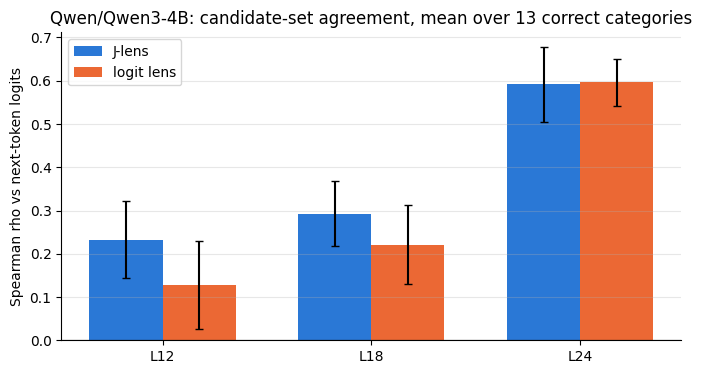

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
positions = np.arange(len(WORKSPACE_LAYERS))
for offset, (name, color) in zip((-width / 2, width / 2),
                                 (("J-lens", "#2a78d6"), ("logit lens", "#eb6834")),
                                 strict=True):
    means = [spearman[spearman.lens.eq(name) & spearman.layer.eq(l)].rho.mean() for l in WORKSPACE_LAYERS]
    errs = [spearman[spearman.lens.eq(name) & spearman.layer.eq(l)].rho.sem() for l in WORKSPACE_LAYERS]
    ax.bar(positions + offset, means, width, yerr=errs, capsize=3, label=name, color=color)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(positions, [f"L{l}" for l in WORKSPACE_LAYERS])
ax.set_ylabel("Spearman rho vs next-token logits")
ax.set_title(f"{MODEL_ID}: candidate-set agreement, "
             f"mean over {len(CORRECT_CATEGORIES)} correct categories")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 4. The causal test: swap the answer for a candidate

For each correctly answered category, swap the model's own answer out for each of the first 10 other
candidates, across a band at every prompt position, and see whether the model then says the
candidate.

In [11]:
@torch.no_grad()
def swap_trial(category, source_id, target_id, band, alpha, mode, generator):
    prompt = build_prompt(category)
    ids = model.encode(prompt)
    layers = BAND_LAYERS[band]
    clean = record_residuals(model, ids, layers)
    with ClampSwap(model, lens, layers, source_id, target_id, alpha=alpha, mode=mode,
                   clean=clean, centers=CENTERS, generator=generator):
        logits = hf_model(input_ids=ids).logits[0, -1].float()
    rank = int((logits > logits[target_id]).sum()) + 1
    return rank, int(logits.argmax())


if OUT_SWAPS.exists():
    swaps = pd.read_csv(OUT_SWAPS)
    print("loaded cache")
else:
    generator = torch.Generator(device="cpu").manual_seed(0)
    records = []
    for category in tqdm(CORRECT_CATEGORIES, desc="categories"):
        words = candidates[category]
        _, model_logits, ids = readout(category, [WORKSPACE_LAYERS[0]])
        answer_id = int(model_logits.argmax())
        answer_word = tokenizer.decode([answer_id]).strip()
        targets = [w for w in words if first_token(w)[1] and w.strip() != answer_word][:10]
        for word in targets:
            target_id = first_token(word)[0]
            base_rank = int((model_logits > model_logits[target_id]).sum()) + 1
            for band in BANDS:
                for alpha in ALPHAS:
                    for mode in MODES:
                        rank, top1 = swap_trial(category, answer_id, target_id, band,
                                                alpha, mode, generator)
                        records.append({
                            "category": category, "answer": answer_word, "target": word,
                            "band": band, "alpha": alpha, "mode": mode,
                            "base_rank": base_rank, "rank": rank,
                            "top1": tokenizer.decode([top1]),
                            "success": rank == 1, "top5": rank <= 5,
                        })
    swaps = pd.DataFrame(records)
    swaps.to_csv(OUT_SWAPS, index=False)
swaps = swaps[swaps.category.isin(CORRECT_CATEGORIES)]
print(len(swaps), "trials")
swaps.head(3)

categories:   0%|          | 0/13 [00:00<?, ?it/s]

3690 trials


,category,answer,target,band,alpha,mode,base_rank,rank,top1,success,top5
0,country,Japan,France,8-16,1.0,J,1,4,Japan,False,True
1,country,Japan,France,8-16,1.0,logit,1,4,Japan,False,True
2,country,Japan,France,8-16,1.0,random,1,2,Japan,False,True


### Swap success rate (target reaches rank 1), by band / alpha / mode

In [12]:
display(swaps.groupby(["mode", "alpha", "band"]).success.mean().unstack("band")[BANDS].round(3))

band           8-16  12-20  16-24  20-28  12-28
mode   alpha                                   
J      1.0    0.041  0.024  0.033  0.195  0.179
       2.0    0.073  0.081  0.081  0.447  0.407
logit  1.0    0.008  0.016  0.065  0.325  0.366
       2.0    0.016  0.033  0.179  0.650  0.659
random 1.0    0.016  0.016  0.016  0.008  0.033
       2.0    0.024  0.008  0.016  0.033  0.041

### And with the looser top-5 criterion

In [13]:
display(swaps.groupby(["mode", "alpha", "band"]).top5.mean().unstack("band")[BANDS].round(3))

band           8-16  12-20  16-24  20-28  12-28
mode   alpha                                   
J      1.0    0.138  0.163  0.163  0.455  0.455
       2.0    0.154  0.260  0.211  0.659  0.659
logit  1.0    0.203  0.220  0.244  0.626  0.618
       2.0    0.228  0.252  0.472  0.854  0.846
random 1.0    0.187  0.187  0.187  0.187  0.187
       2.0    0.171  0.179  0.211  0.187  0.211

### Best setting per mode, with Wilson 95% intervals

The J arm must beat both controls for the claim to hold.

In [14]:
def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


grouped = swaps.groupby(["mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
best = grouped.loc[grouped.groupby("mode")["sum"].idxmax()].copy()
best["rate"] = (best["sum"] / best["size"]).round(3)
best["CI lo"], best["CI hi"] = wilson(best["sum"], best["size"])
display(best.round(3))

,mode,alpha,band,sum,size,rate,CI lo,CI hi
8,J,2.0,20-28,55,123,0.447,0.362,0.535
16,logit,2.0,12-28,81,123,0.659,0.571,0.736
26,random,2.0,12-28,5,123,0.041,0.017,0.092


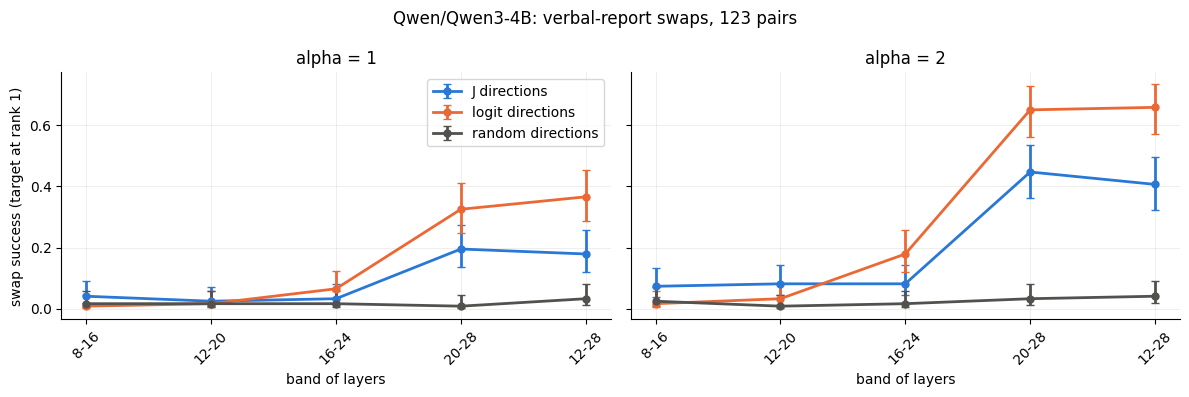

In [15]:
COLORS = {"J": "#2a78d6", "logit": "#eb6834", "random": "#52514e"}
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(6 * len(ALPHAS), 4), sharey=True)
for ax, alpha in zip(np.atleast_1d(axes), ALPHAS, strict=True):
    for mode, color in COLORS.items():
        sub = grouped[grouped["mode"].eq(mode) & grouped.alpha.eq(alpha)].set_index("band").loc[BANDS]
        rate = sub["sum"] / sub["size"]
        lo, hi = wilson(sub["sum"], sub["size"])
        ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=color,
                    marker="o", ms=5, lw=2, capsize=3, label=f"{mode} directions")
    ax.set_xticks(range(len(BANDS)), BANDS, rotation=45)
    ax.set_title(f"alpha = {alpha:g}")
    ax.set_xlabel("band of layers")
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
np.atleast_1d(axes)[0].set_ylabel("swap success (target at rank 1)")
np.atleast_1d(axes)[0].legend()
fig.suptitle(f"{MODEL_ID}: verbal-report swaps, {len(swaps) // (len(BANDS) * len(ALPHAS) * len(MODES))} pairs")
fig.tight_layout()
plt.show()

### Median log10 rank gain of the swapped-in candidate

In [16]:
swaps["log10 rank gain"] = np.log10(swaps.base_rank) - np.log10(swaps["rank"])
display(swaps.groupby(["mode", "alpha", "band"])["log10 rank gain"].median().unstack("band")[BANDS].round(2))

band          8-16  12-20  16-24  20-28  12-28
mode   alpha                                  
J      1.0   -0.14  -0.04  -0.05   0.37   0.35
       2.0   -0.33  -0.12  -0.11   0.74   0.64
logit  1.0    0.01   0.04   0.18   0.63   0.64
       2.0    0.05   0.11   0.40   1.00   1.00
random 1.0    0.00   0.00   0.00   0.00   0.00
       2.0    0.00   0.00   0.00   0.00   0.00

### A worked example

In [17]:
example = swaps[swaps["mode"].eq("J") & swaps.success].head(12)
display(example[["category", "answer", "target", "band", "alpha", "base_rank", "rank", "top1"]])

,category,answer,target,band,alpha,base_rank,rank,top1
18,country,Japan,France,20-28,1.0,1,1,France
21,country,Japan,France,20-28,2.0,1,1,France
24,country,Japan,France,12-28,1.0,1,1,France
27,country,Japan,France,12-28,2.0,1,1,France
78,country,Japan,China,20-28,1.0,4,1,China
81,country,Japan,China,20-28,2.0,4,1,China
84,country,Japan,China,12-28,1.0,4,1,China
87,country,Japan,China,12-28,2.0,4,1,China
105,country,Japan,India,16-24,2.0,7,1,India
111,country,Japan,India,20-28,2.0,7,1,India


## 5. Conclusions

All numbers are on the 13 categories the model answers with one of their candidates (§2).

* **The paper's readout metric reproduces in mid-network.** Spearman rho between the lens
  and the model's own next-token logits over each category's candidate set is higher for
  the J-lens at layers 12 (0.23 vs 0.13) and 18 (0.29 vs 0.22), and the two converge at
  layer 24 (0.59 vs 0.60), which is what should happen — there `J_l` is close to the
  identity. The J-lens's advantage is therefore in the middle of the network, where the
  paper puts the workspace.
* **It is not uniform across categories.** `instrument`, `city` and `organ` reach rho
  0.88-0.95 at layer 24; `river` is negative (-0.18) and `planet` stays weak (0.31). With
  13 categories, the per-layer means carry standard deviations of about 0.3, so the layer-12
  and layer-18 gaps are suggestive rather than tight.
* **Swapping the J-space coordinate changes the reported word.** 44.7% of swaps put the
  target at rank 1, against 4.1% for random directions of the same per-position norm — a
  ten-fold separation with non-overlapping Wilson intervals. On the looser top-5 criterion
  the J arm reaches 66%. The verbal report is therefore reading content that is causally
  responsible for the answer, not an epiphenomenal correlate.
* **But in *this* setup `J_l` is not what carries the swap.** Logit-lens directions, the
  identical clamp with `J_l = I`, succeed 65.9% of the time — well above the J arm. The J
  arm leads only in the two early bands (8-16, 12-20: 0.07-0.08 vs 0.02-0.03 at alpha 2),
  where both are weak in absolute terms, and its median rank gain there is negative. This
  is worth contrasting with `concept_swap.ipynb`, where on factual-recall prompts the J arm
  beats logit at *every* early band and logit scores exactly 0.000. The difference between
  the two experiments is what the source concept is: there it is a word present in the
  prompt (*France*), here it is the model's own free choice (*Japan*), which is never
  written down. A clean J-space coordinate for a token the prompt never contains is
  evidently harder to read off, and at late depth the plain unembedding direction does the
  job better.
* **Caveats.** 13 categories and 123 answer-candidate pairs per setting; one model, one
  lens. The model's answer is its greedy token, so a multi-token answer is scored on its
  first token. A rank-1 tie counts as success; one pair (`country`: Japan -> France) is
  tied at baseline in bf16, and excluding it moves the best J rate to 44.3%. The model's
  greedy answers drift slightly across library versions (`instrument` was `piano` in an
  earlier run, `Guitar` here), so the swap cache was rebuilt. Bands were chosen as
  fractions of depth, not measured. bf16 throughout, matching the dtype the lens was fitted
  in.